# SARIMA - Predicción de ventas semanales en retail

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Series Temporales · ARIMA/SARIMA

---

Modelo SARIMA para anticipar las ventas semanales y apoyar decisiones de **stock, personal y planificación comercial**.


### Contexto de negocio

Una cadena de supermercados necesita anticipar las ventas semanales para planificar inventario, personal y promociones.

El problema tiene dos riesgos principales:

- **Sobrestock** en semanas de baja demanda → más costes de almacenamiento y merma.
- **Roturas de stock** en semanas de alta demanda → pérdida de ventas.

La pregunta es sencilla:

**¿Podemos predecir las ventas de las próximas semanas capturando la tendencia y la estacionalidad anual?**

### Objetivo y elección del modelo

La serie presenta una **estacionalidad anual de 52 semanas** y una tendencia. Por ello utilizamos **SARIMA**, una extensión de ARIMA capaz de modelar tanto la dinámica temporal como la estacionalidad.

# Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Estilo visual -- sistema de color validado (consejo UX/UI Data)
BACKGROUND    = "#fbfbfb"
PURPLE        = "#7a7bff"
PURPLE_LIGHT  = "#9b9cff"
POSITIVE      = "#6b8158"
NEGATIVE      = "#c34031"
NEUTRAL_BAR   = "#d9d9d9"
NEUTRAL_LINE  = "#8f8c9e"
CONTEXT_LINES = [NEUTRAL_LINE, "#a89a8a", "#7d94a8"]
INK           = "#111111"
MUTED         = "#707070"

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 100,
    "figure.facecolor": BACKGROUND,
    "axes.facecolor": BACKGROUND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.family": "sans-serif",
    "font.size": 10,
    "grid.color": "#f0f0f0",
    "grid.linewidth": 0.5,
})

pd.set_option("display.max_columns", None)

## Carga y exploración inicial

**Periodo:** enero de 2020 a diciembre de 2024.  
**Frecuencia:** semanal.  
**Observaciones:** 260 semanas.


In [2]:
# Carga de datos
df = pd.read_excel(
    "arima.xlsx",
    parse_dates=["Fecha"],
    index_col="Fecha"
)

# Frecuencia semanal explícita
df = df.asfreq("W-SUN")

print(f"Registros:  {len(df)}")
print(f"Periodo:    {df.index.min().date()} → {df.index.max().date()}")
print(f"Frecuencia: {df.index.freq}")
print(f"Nulos:      {df.isnull().sum().sum()}")

print("\nEstadísticos descriptivos:")
display(df.describe().round(0))


Registros:  260
Periodo:    2020-01-05 → 2024-12-22
Frecuencia: <Week: weekday=6>
Nulos:      0

Estadísticos descriptivos:


,Ventas
count,260.0
mean,156022.0
std,21551.0
min,113384.0
25%,137274.0
50%,156197.0
75%,173353.0
max,207441.0


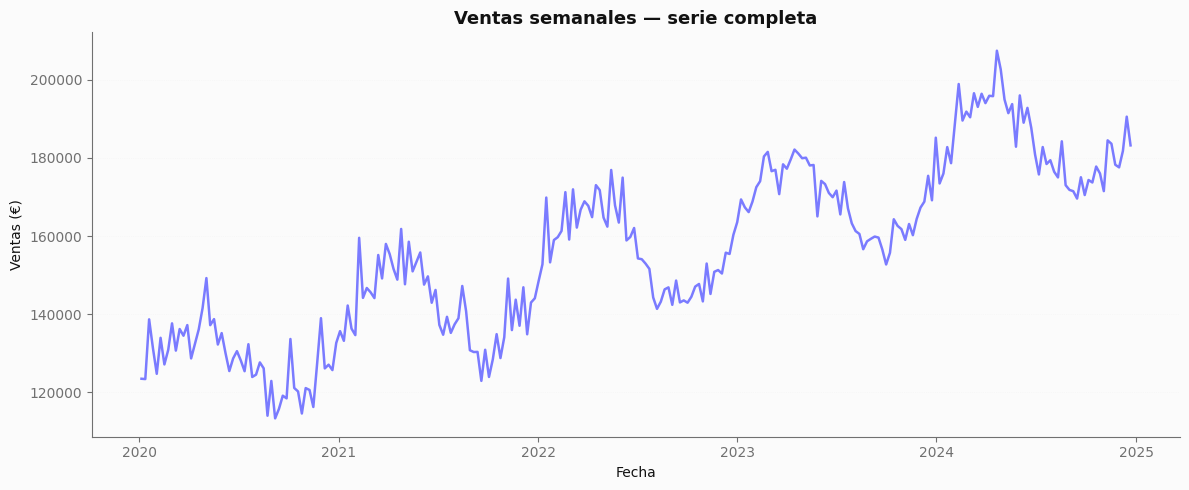

In [3]:
# Visualización de la serie completa

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    df.index,
    df["Ventas"],
    color=PURPLE,
    linewidth=1.8
)

ax.set_title("Ventas semanales — serie completa")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas (€)")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


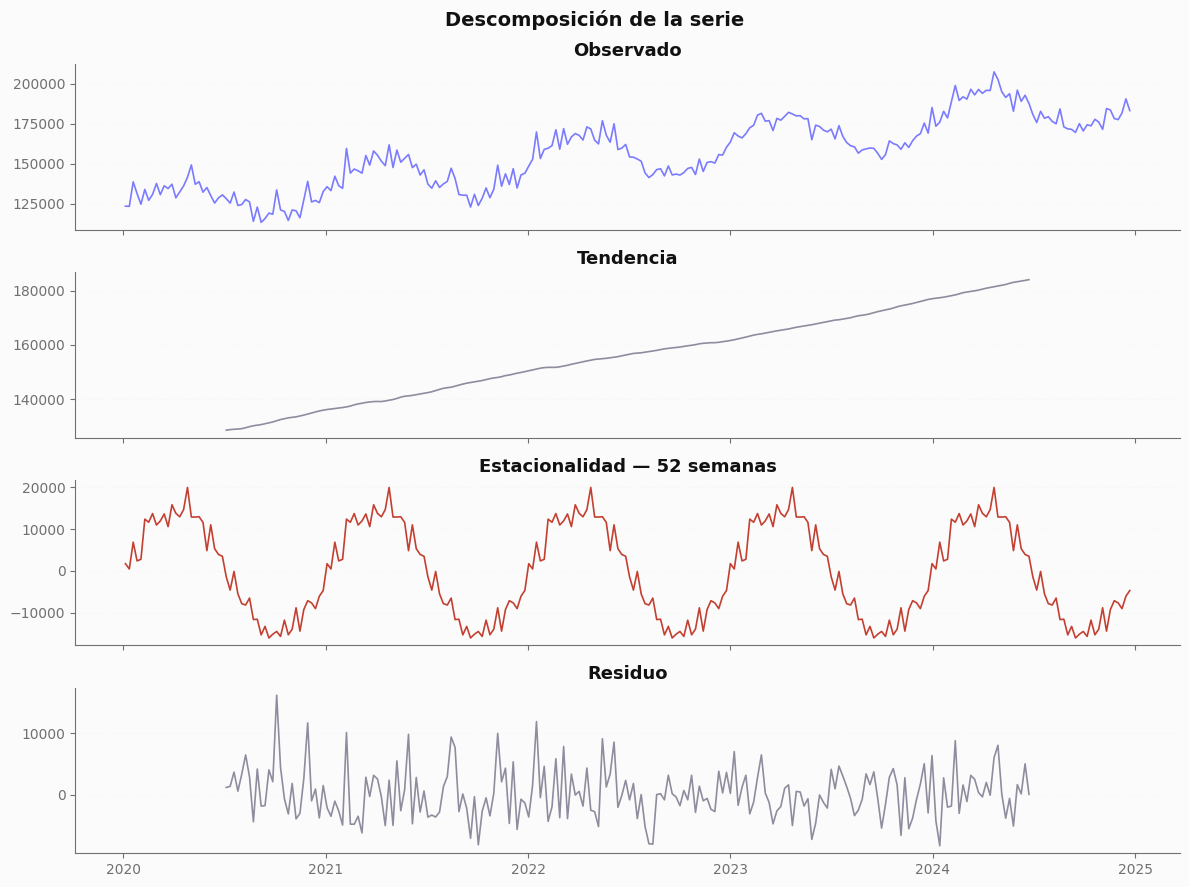

In [4]:
# Descomposición de la serie
# Periodo 52 = estacionalidad anual en datos semanales

decomp = seasonal_decompose(
    df["Ventas"],
    model="additive",
    period=52
)

fig, axes = plt.subplots(
    4, 1,
    figsize=(12, 9),
    sharex=True
)

componentes = [
    (decomp.observed, "Observado", PURPLE),
    (decomp.trend, "Tendencia", CONTEXT_LINES[0]),
    (decomp.seasonal, "Estacionalidad — 52 semanas", NEGATIVE),
    (decomp.resid, "Residuo", NEUTRAL_LINE),
]
for ax, (serie, titulo, color) in zip(axes, componentes):
    ax.plot(serie.index, serie, color=color, linewidth=1.2)
    ax.set_title(titulo)
    ax.grid(axis="y", linestyle=":", alpha=0.6)

fig.suptitle(
    "Descomposición de la serie",
    fontsize=14,
    fontweight="bold",
    color=INK
)

plt.tight_layout()
plt.show()


# Separación temporal Train / Test

En series temporales **no hacemos un split aleatorio**.

El modelo debe aprender únicamente del pasado y evaluarse sobre un periodo posterior. Por eso reservamos el **20% final de las semanas** como conjunto de test.


In [5]:
# Train / Test cronológico: 80% / 20%

split = int(len(df) * 0.80)

train = df.iloc[:split].copy()
test = df.iloc[split:].copy()

print(
    f"Train: {len(train)} semanas "
    f"({train.index.min().date()} → {train.index.max().date()})"
)

print(
    f"Test:  {len(test)} semanas "
    f"({test.index.min().date()} → {test.index.max().date()})"
)


Train: 208 semanas (2020-01-05 → 2023-12-24)
Test:  52 semanas (2023-12-31 → 2024-12-22)


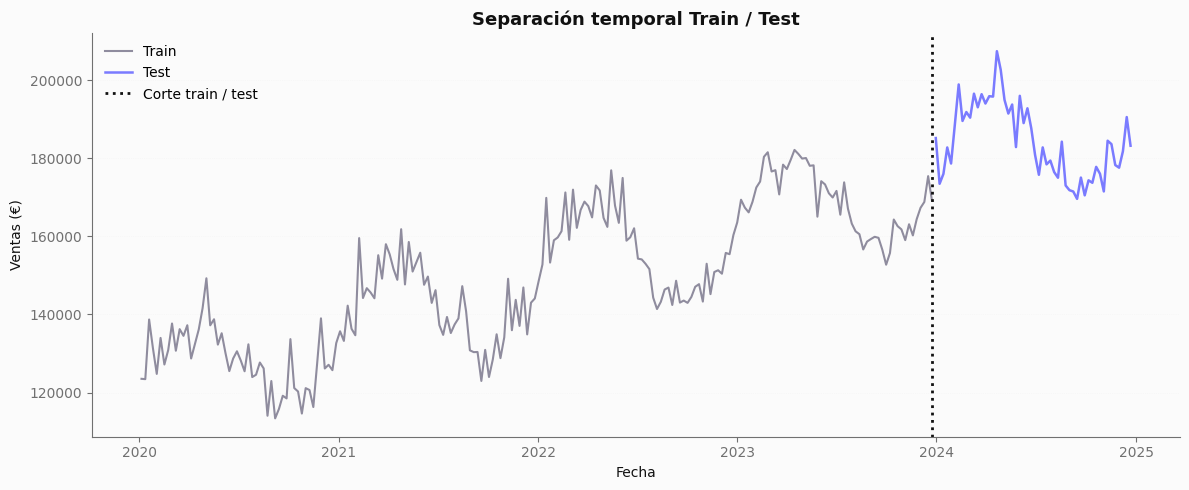

In [6]:
# Visualización de la separación temporal

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    train.index,
    train["Ventas"],
    color=NEUTRAL_LINE,
    linewidth=1.5,
    label="Train"
)

ax.plot(
    test.index,
    test["Ventas"],
    color=PURPLE,
    linewidth=1.8,
    label="Test"
)

ax.axvline(
    train.index[-1],
    color=INK,
    linestyle=":",
    linewidth=2,
    label="Corte train / test"
)

ax.set_title("Separación temporal Train / Test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas (€)")
ax.legend(frameon=False)

ax.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


## Análisis de estacionariedad

ARIMA/SARIMA necesita trabajar con una serie estacionaria.

Utilizamos el **test de Dickey-Fuller Aumentado (ADF)**:

- **H₀:** la serie no es estacionaria.
- **p-valor < 0,05:** rechazamos H₀ → evidencia de estacionariedad.
- **p-valor ≥ 0,05:** no rechazamos H₀ → necesitamos transformar la serie.

Primero comprobamos la serie original y después aplicamos una diferenciación de primer orden (`d=1`).


In [7]:
# ADF sobre la serie original

resultado_adf = adfuller(train["Ventas"])

print("ADF — serie original")
print(f"Estadístico: {resultado_adf[0]:.4f}")
print(f"p-valor:     {resultado_adf[1]:.4f}")

if resultado_adf[1] < 0.05:
    print("Conclusión: existe evidencia de estacionariedad.")
else:
    print("Conclusión: la serie no es estacionaria → aplicamos d=1.")


ADF — serie original
Estadístico: -1.2482
p-valor:     0.6525
Conclusión: la serie no es estacionaria → aplicamos d=1.


In [8]:
# Diferenciación de primer orden

train_diff = train["Ventas"].diff().dropna()

resultado_adf_diff = adfuller(train_diff)

print("ADF — serie diferenciada (d=1)")
print(f"Estadístico: {resultado_adf_diff[0]:.4f}")
print(f"p-valor:     {resultado_adf_diff[1]:.6f}")

if resultado_adf_diff[1] < 0.05:
    print("Conclusión: la serie diferenciada es estacionaria.")
else:
    print("Conclusión: todavía no hay evidencia suficiente de estacionariedad.")


ADF — serie diferenciada (d=1)
Estadístico: -14.8895
p-valor:     0.000000
Conclusión: la serie diferenciada es estacionaria.


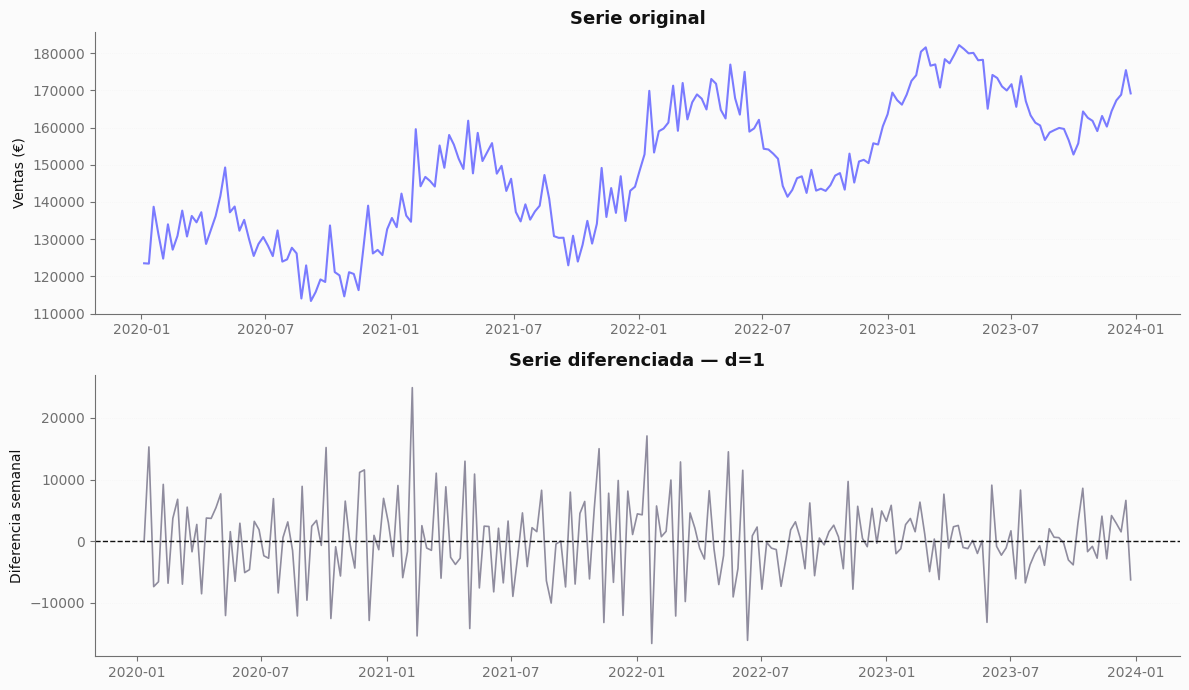

In [9]:
# Serie original vs serie diferenciada

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

axes[0].plot(
    train.index,
    train["Ventas"],
    color=PURPLE,
    linewidth=1.5
)
axes[0].set_title("Serie original")
axes[0].set_ylabel("Ventas (€)")
axes[0].grid(axis="y", linestyle=":", alpha=0.6)

axes[1].plot(
    train_diff.index,
    train_diff,
    color=CONTEXT_LINES[0],
    linewidth=1.2
)
axes[1].axhline(0, color=INK, linestyle="--", linewidth=1)
axes[1].set_title("Serie diferenciada — d=1")
axes[1].set_ylabel("Diferencia semanal")
axes[1].grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


## Identificación de parámetros: ACF y PACF

La **ACF** ayuda a identificar la parte MA (`q`) y la **PACF** aporta información sobre la parte AR (`p`).

Además, los picos alrededor de los múltiplos de **52 semanas** son una señal de estacionalidad anual.

> ACF y PACF no deben interpretarse como una regla mecánica: sirven para proponer candidatos que después deben comprobarse mediante el ajuste y el diagnóstico de residuos.


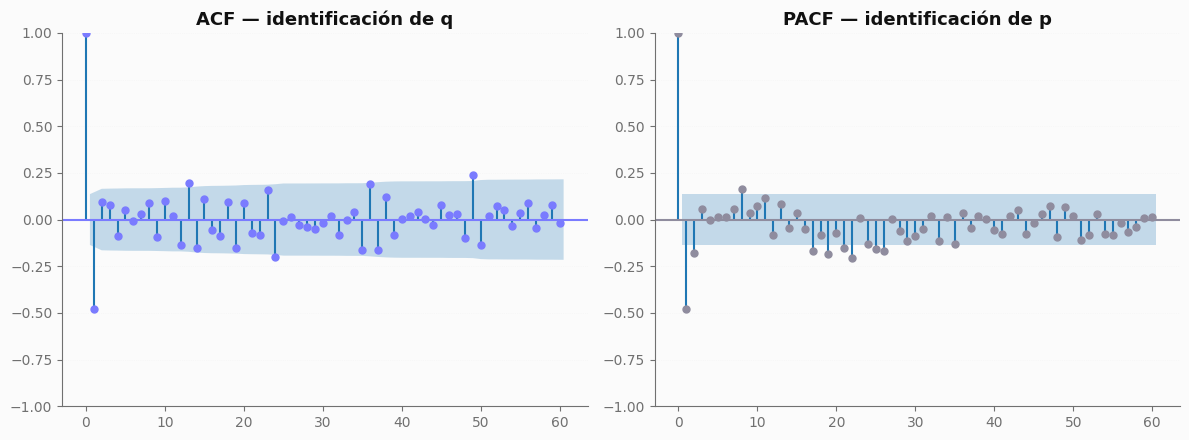

In [10]:
# ACF y PACF sobre la serie diferenciada

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

plot_acf(
    train_diff,
    lags=60,
    ax=axes[0],
    color=PURPLE
)
axes[0].set_title("ACF — identificación de q")

plot_pacf(
    train_diff,
    lags=60,
    ax=axes[1],
    color=CONTEXT_LINES[0],
    method="ywm"
)
axes[1].set_title("PACF — identificación de p")

for ax in axes:
    ax.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


## 8. Modelo SARIMA

A partir del análisis anterior utilizamos:

| Componente | Valor | Interpretación |
|:--|--:|:--|
| `p` | 0 | Parte autorregresiva no estacional |
| `d` | 1 | Diferenciación para estacionarizar |
| `q` | 1 | Componente de media móvil |
| `P` | 0 | Parte AR estacional |
| `D` | 1 | Diferenciación estacional |
| `Q` | 1 | Componente MA estacional |
| `s` | 52 | Ciclo anual semanal |

**Modelo:** `SARIMA(0,1,1)(0,1,1,52)`

La elección debe entenderse como un **modelo candidato**, cuya validez se comprueba posteriormente mediante los residuos y el rendimiento sobre datos no vistos.


In [11]:
# Entrenamiento del modelo SARIMA

modelo = SARIMAX(
    train["Ventas"],
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_fit = modelo.fit(disp=False)

print(resultado_fit.summary())


c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                             Ventas   No. Observations:                  208
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 52)   Log Likelihood               -1026.544
Date:                            Mon, 21 Sep 2026   AIC                           2059.087
Time:                                    12:42:35   BIC                           2066.933
Sample:                                01-05-2020   HQIC                          2062.263
                                     - 12-24-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7398      0.104     -7.129      0.000      -0.943      -0.536
ma.S.L52      -0.3873      0.094   

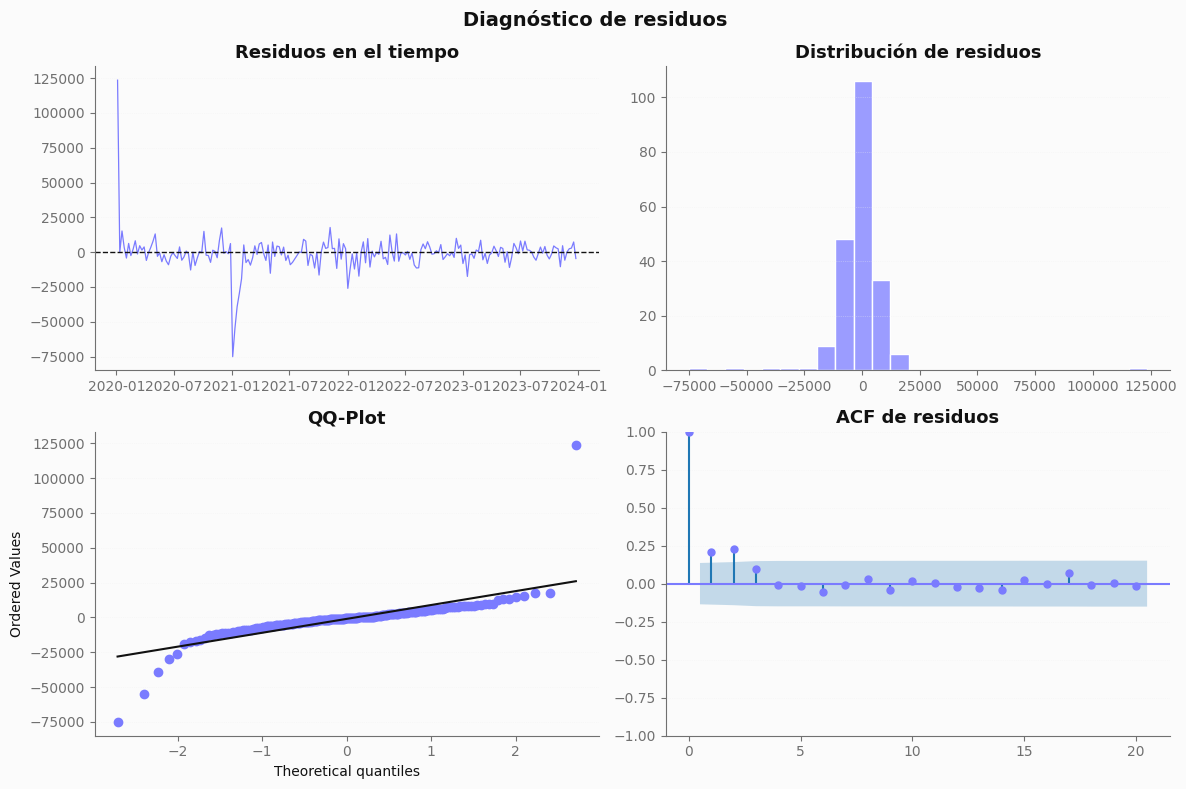


Test de Ljung-Box


,lb_stat,lb_pvalue
10,23.3048,0.0097
20,25.2624,0.1916


In [12]:
# Diagnóstico de residuos

resid = resultado_fit.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(
    resid.index,
    resid,
    color=PURPLE,
    linewidth=0.9
)
axes[0, 0].axhline(0, color=INK, linestyle="--", linewidth=1)
axes[0, 0].set_title("Residuos en el tiempo")

axes[0, 1].hist(
    resid,
    bins=25,
    color=PURPLE_LIGHT,
    edgecolor="white"
)
axes[0, 1].set_title("Distribución de residuos")

from scipy import stats
stats.probplot(
    resid,
    dist="norm",
    plot=axes[1, 0]
)
axes[1, 0].get_lines()[0].set_color(PURPLE)
axes[1, 0].get_lines()[1].set_color(INK)
axes[1, 0].set_title("QQ-Plot")

plot_acf(
    resid,
    lags=min(20, len(resid)//3),
    ax=axes[1, 1],
    color=PURPLE
)
axes[1, 1].set_title("ACF de residuos")

for ax in axes.ravel():
    ax.grid(axis="y", linestyle=":", alpha=0.6)

plt.suptitle(
    "Diagnóstico de residuos",
    fontsize=14,
    fontweight="bold",
    color=INK
)

plt.tight_layout()
plt.show()

# Ljung-Box: comprobamos si queda autocorrelación significativa
lb = acorr_ljungbox(
    resid,
    lags=[10, 20],
    return_df=True
)

print("\nTest de Ljung-Box")
display(lb.round(4))


### ¿Qué buscamos en los residuos?

Un modelo adecuado debería dejar residuos que se comporten aproximadamente como **ruido blanco**:

- Sin tendencia o patrón visible.
- Sin autocorrelación relevante.
- Distribución razonablemente centrada alrededor de cero.

El **Ljung-Box** complementa la inspección visual: un p-valor superior a 0,05 indica que no tenemos evidencia suficiente de autocorrelación residual en ese lag.


## Evaluación sobre datos no vistos

Ahora hacemos la prueba realmente importante: **predecir las 52 semanas del conjunto de test sin utilizar sus valores reales durante el entrenamiento**.

Las métricas principales serán:

- **MAE:** error medio en euros.
- **RMSE:** penaliza especialmente los errores grandes.
- **MAPE:** error porcentual medio, más fácil de interpretar en negocio.


In [13]:
# Forecast sobre el horizonte completo de test

pred = resultado_fit.get_forecast(steps=len(test))

pred_media = pred.predicted_mean
pred_ic = pred.conf_int()

# Métricas
mae = mean_absolute_error(test["Ventas"], pred_media)
rmse = np.sqrt(mean_squared_error(test["Ventas"], pred_media))

mape = (
    np.mean(
        np.abs(
            (test["Ventas"] - pred_media) / test["Ventas"]
        )
    ) * 100
)

error_rel = (
    mae / test["Ventas"].mean()
) * 100

print("Evaluación sobre test")
print(f"MAE:            {mae:,.0f} €")
print(f"RMSE:           {rmse:,.0f} €")
print(f"Ventas medias:  {test['Ventas'].mean():,.0f} €/semana")
print(f"Error relativo: {error_rel:.2f}%")
print(f"MAPE:           {mape:.2f}%")
print(f"RMSE / MAE:     {rmse / mae:.2f}")


Evaluación sobre test
MAE:            4,035 €
RMSE:           4,981 €
Ventas medias:  184,304 €/semana
Error relativo: 2.19%
MAPE:           2.21%
RMSE / MAE:     1.23


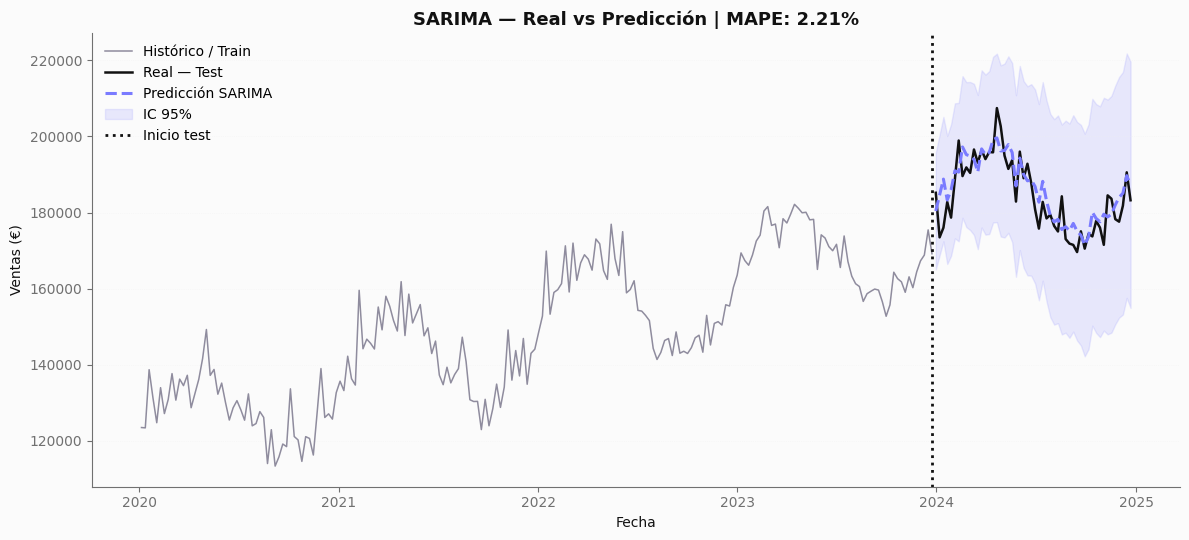

In [14]:
# Predicción vs realidad

fig, ax = plt.subplots(figsize=(12, 5.5))

ax.plot(
    train.index,
    train["Ventas"],
    color=NEUTRAL_LINE,
    linewidth=1.1,
    label="Histórico / Train"
)

ax.plot(
    test.index,
    test["Ventas"],
    color=INK,
    linewidth=1.8,
    label="Real — Test"
)

ax.plot(
    test.index,
    pred_media,
    color=PURPLE,
    linewidth=2.2,
    linestyle="--",
    label="Predicción SARIMA"
)

ax.fill_between(
    test.index,
    pred_ic.iloc[:, 0],
    pred_ic.iloc[:, 1],
    color=PURPLE,
    alpha=0.15,
    label="IC 95%"
)

ax.axvline(
    train.index[-1],
    color=INK,
    linestyle=":",
    linewidth=2,
    label="Inicio test"
)

ax.set_title(
    f"SARIMA — Real vs Predicción | MAPE: {mape:.2f}%",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas (€)")
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


## Forecast de las próximas 20 semanas

Una vez evaluado el modelo, lo reentrenamos con **toda la información histórica disponible**.

El objetivo ya no es evaluar el modelo, sino generar una previsión operativa para las **20 semanas siguientes**.

Importante: el intervalo de confianza no es un objetivo de ventas; representa la incertidumbre alrededor de la previsión.


In [ ]:
# Reentrenamiento con toda la serie

modelo_final = SARIMAX(
    df["Ventas"],
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_final = modelo_final.fit(disp=False)

# Forecast a 20 semanas
horizonte = 20

forecast = resultado_final.get_forecast(
    steps=horizonte
)

fc_media = forecast.predicted_mean
fc_ic = forecast.conf_int()

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(weeks=1),
    periods=horizonte,
    freq="W-SUN"
)

print(f"Horizonte: {horizonte} semanas")
print(f"Desde:     {future_dates[0].date()}")
print(f"Hasta:     {future_dates[-1].date()}")
print(f"Media prevista: {fc_media.mean():,.0f} €/semana")


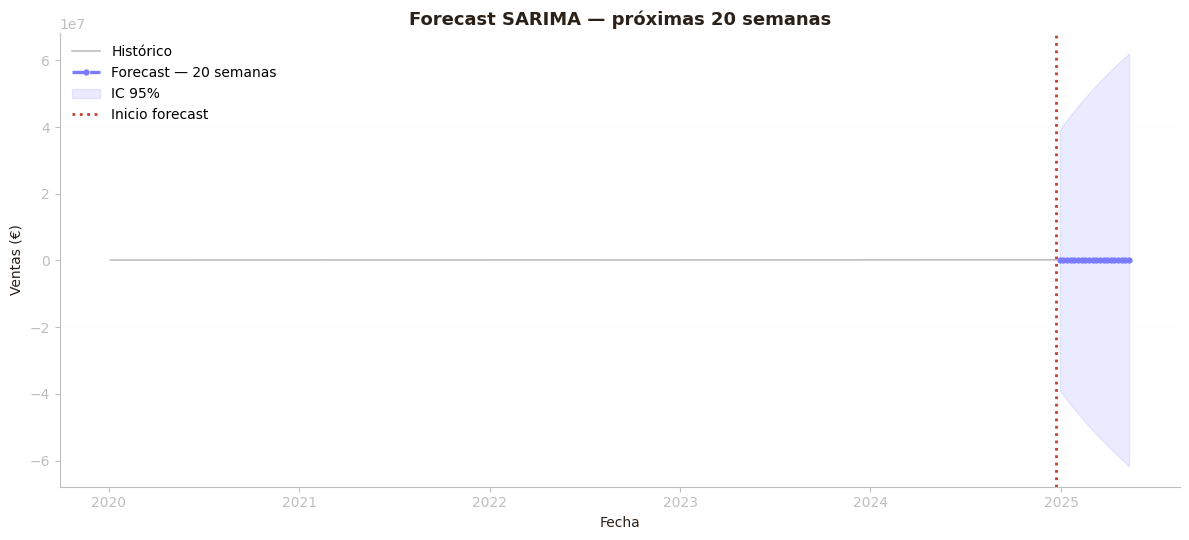

In [ ]:
# Visualización del forecast

fig, ax = plt.subplots(figsize=(12, 5.5))

ax.plot(
    df.index,
    df["Ventas"],
    color=NEUTRAL_LINE,
    linewidth=1.2,
    label="Histórico"
)

ax.plot(
    future_dates,
    fc_media.values,
    color=PURPLE,
    linewidth=2.4,
    linestyle="--",
    marker="o",
    markersize=3.5,
    label="Forecast — 20 semanas"
)

ax.fill_between(
    future_dates,
    fc_ic.iloc[:, 0].values,
    fc_ic.iloc[:, 1].values,
    color=PURPLE,
    alpha=0.15,
    label="IC 95%"
)

ax.axvline(
    df.index[-1],
    color=INK,
    linestyle=":",
    linewidth=2,
    label="Inicio forecast"
)

ax.set_title(
    "Forecast SARIMA — próximas 20 semanas",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas (€)")
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


## 11. Resumen de resultados

| Indicador | Resultado |
|:--|--:|
| Modelo | SARIMA(0,1,1)(0,1,1,52) |
| Periodicidad | 52 semanas |
| Train | 208 semanas |
| Test | 52 semanas |
| MAE | 4.035 € |
| RMSE | 4.981 € |
| MAPE | **2,21%** |
| Error relativo | **2,19%** |
| Forecast futuro | 20 semanas |

### Lectura de negocio

El modelo presenta un **MAPE del 2,21% sobre el conjunto de test**, por lo que, en promedio, la predicción se desvía aproximadamente un 2,2% de las ventas reales.

Con unas ventas medias de test de aproximadamente **184.300 € por semana**, el MAE de **4.035 €** proporciona una referencia clara del error medio en euros.


## Conclusión y recomendaciones

La serie de ventas presenta una estructura temporal clara: **tendencia y estacionalidad anual**. La diferenciación (`d=1`) consigue estacionarizar la serie y el modelo **SARIMA(0,1,1)(0,1,1,52)** consigue capturar buena parte de la dinámica semanal.

El resultado sobre datos no vistos es sólido:

**MAPE = 2,21% y MAE ≈ 4.035 € por semana.**

Esto significa que el modelo ofrece una previsión suficientemente precisa para utilizarse como **herramienta de apoyo a la planificación operativa**, siempre teniendo en cuenta que el rendimiento observado corresponde a este periodo histórico y debe monitorizarse cuando cambien las condiciones del negocio.

### Recomendaciones

**1. Planificar inventario**  
Utilizar el forecast para anticipar semanas de mayor y menor demanda.

**2. Ajustar personal**  
Relacionar las ventas previstas con las necesidades de caja, reposición y logística.

**3. Monitorizar el error**  
Comparar semanalmente ventas reales frente a predicciones. Un aumento sostenido del error puede indicar un cambio estructural.

**4. Revisar el modelo periódicamente**  
El patrón histórico puede cambiar por promociones, aperturas, competencia o cambios en el comportamiento del consumidor.

### Insight final

**El valor del modelo no está únicamente en predecir ventas, sino en convertir esa previsión en una decisión operativa: cuánto comprar, cuánto personal asignar y cuándo anticiparse a un pico de demanda.**
